# Vulcan Materials Risk Modeling

Comprehensive risk analytics following Power & Utilities patterns:
1. **Value at Risk (VaR)** - Historical and Parametric approaches
2. **Expected Shortfall (CVaR)** - Tail risk measurement
3. **Revenue Volatility Analysis** - Rolling volatility metrics
4. **Stress Testing** - Economic downturn scenarios

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import snowflake.connector
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
conn = snowflake.connector.connect(connection_name=os.getenv('SNOWFLAKE_CONNECTION_NAME') or 'my_snowflake')
print('Connected to Snowflake')

Connected to Snowflake


In [10]:
query = """
SELECT YEAR_MONTH, SUM(REVENUE_USD) as TOTAL_REVENUE, SUM(SHIPMENT_TONS) as TOTAL_SHIPMENTS
FROM VULCAN_MATERIALS_DB.ATOMIC.MONTHLY_SHIPMENTS
WHERE SHIPMENT_TONS > 0
GROUP BY YEAR_MONTH ORDER BY YEAR_MONTH
"""
df = pd.read_sql(query, conn)
df['YEAR_MONTH'] = pd.to_datetime(df['YEAR_MONTH'])
df = df.set_index('YEAR_MONTH')
df['RETURNS'] = df['TOTAL_REVENUE'].pct_change()
print(f'Loaded {len(df)} months of data')

Loaded 74 months of data


In [11]:
class RevenueRiskAnalyzer:
    def __init__(self, returns):
        self.returns = returns.dropna()
        self.mu = self.returns.mean()
        self.sigma = self.returns.std()
    
    def historical_var(self, confidence=0.95):
        return np.percentile(self.returns, (1-confidence)*100)
    
    def parametric_var(self, confidence=0.95):
        z = stats.norm.ppf(1-confidence)
        return self.mu + z * self.sigma
    
    def cvar(self, confidence=0.95):
        var = self.historical_var(confidence)
        return self.returns[self.returns <= var].mean()
    
    def rolling_volatility(self, window=12):
        return self.returns.rolling(window).std() * np.sqrt(12)

risk = RevenueRiskAnalyzer(df['RETURNS'])
var_95 = risk.historical_var(0.95)
var_99 = risk.historical_var(0.99)
cvar_95 = risk.cvar(0.95)
print(f'95% VaR: {var_95:.2%}')
print(f'99% VaR: {var_99:.2%}')
print(f'95% CVaR: {cvar_95:.2%}')

95% VaR: -34.82%
99% VaR: -48.55%
95% CVaR: -45.02%


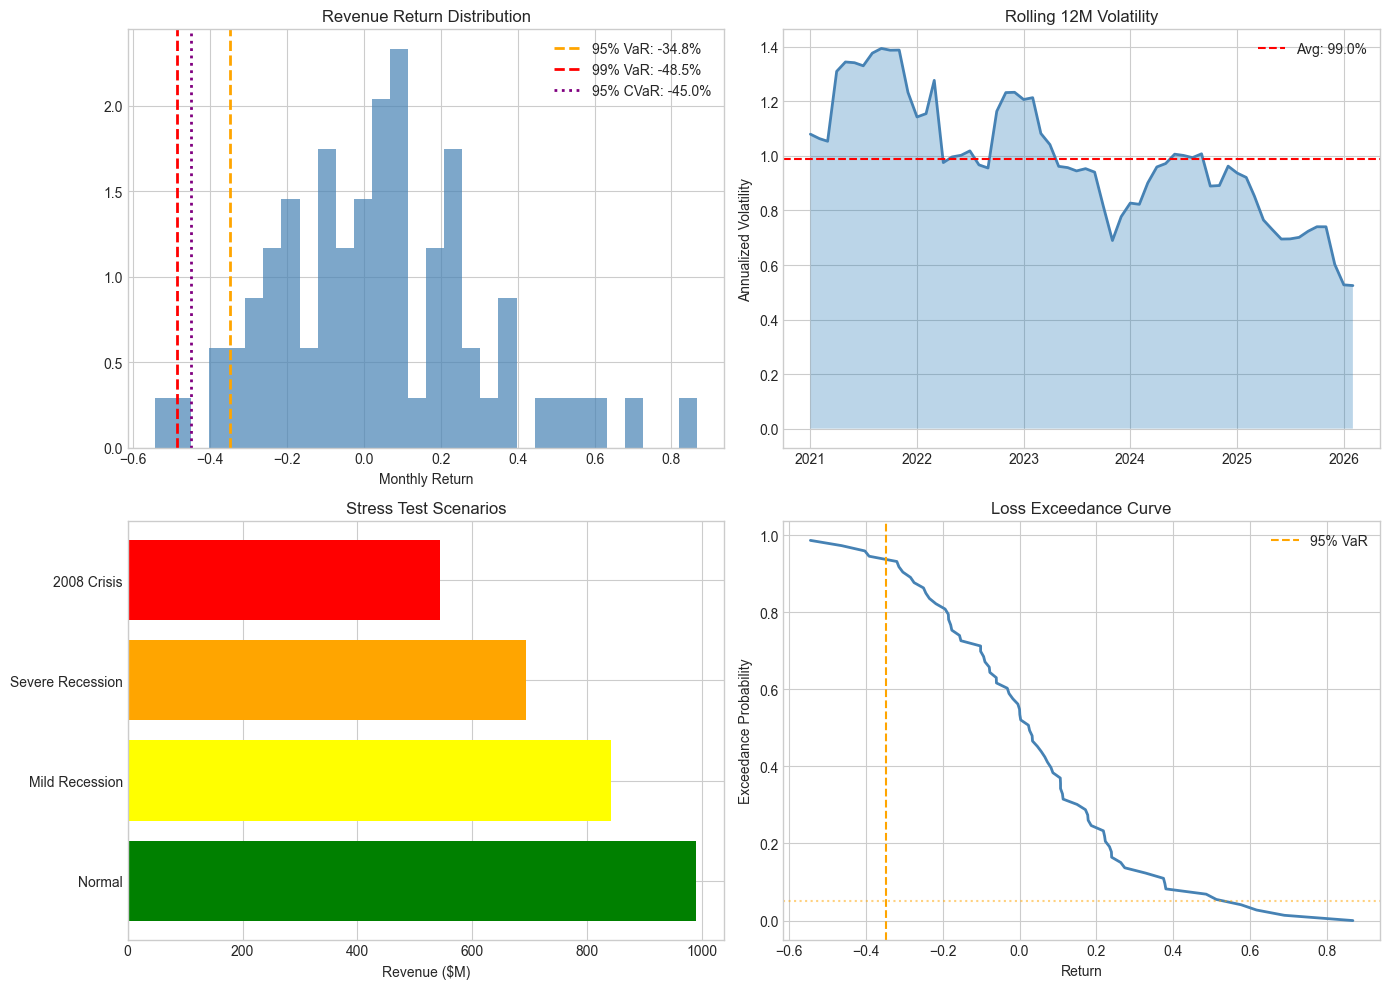

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
ax.hist(df['RETURNS'].dropna(), bins=30, density=True, alpha=0.7, color='steelblue')
ax.axvline(var_95, color='orange', ls='--', lw=2, label=f'95% VaR: {var_95:.1%}')
ax.axvline(var_99, color='red', ls='--', lw=2, label=f'99% VaR: {var_99:.1%}')
ax.axvline(cvar_95, color='purple', ls=':', lw=2, label=f'95% CVaR: {cvar_95:.1%}')
ax.set_xlabel('Monthly Return')
ax.set_title('Revenue Return Distribution')
ax.legend()

ax = axes[0, 1]
rolling_vol = risk.rolling_volatility(12).dropna()
ax.plot(rolling_vol.index, rolling_vol.values, color='steelblue', lw=2)
ax.axhline(rolling_vol.mean(), color='r', ls='--', label=f'Avg: {rolling_vol.mean():.1%}')
ax.fill_between(rolling_vol.index, 0, rolling_vol.values, alpha=0.3)
ax.set_ylabel('Annualized Volatility')
ax.set_title('Rolling 12M Volatility')
ax.legend()

ax = axes[1, 0]
stress_scenarios = {'Normal': 0, 'Mild Recession': -0.15, 'Severe Recession': -0.30, '2008 Crisis': -0.45}
current_revenue = df['TOTAL_REVENUE'].iloc[-1]
stressed = [current_revenue * (1 + s) / 1e6 for s in stress_scenarios.values()]
colors = ['green', 'yellow', 'orange', 'red']
ax.barh(list(stress_scenarios.keys()), stressed, color=colors)
ax.set_xlabel('Revenue ($M)')
ax.set_title('Stress Test Scenarios')

ax = axes[1, 1]
returns = df['RETURNS'].dropna()
sorted_returns = np.sort(returns)
n = len(sorted_returns)
exceedance = np.arange(1, n+1) / n
ax.plot(sorted_returns, 1-exceedance, color='steelblue', lw=2)
ax.axvline(var_95, color='orange', ls='--', label='95% VaR')
ax.axhline(0.05, color='orange', ls=':', alpha=0.5)
ax.set_xlabel('Return')
ax.set_ylabel('Exceedance Probability')
ax.set_title('Loss Exceedance Curve')
ax.legend()

plt.tight_layout()
plt.show()

In [13]:
print('=' * 60)
print('RISK ANALYSIS SUMMARY')
print('=' * 60)
print(f'Historical 95% VaR: {var_95:.2%}')
print(f'Historical 99% VaR: {var_99:.2%}')
print(f'Expected Shortfall (CVaR 95%): {cvar_95:.2%}')
print(f'Average Annualized Volatility: {rolling_vol.mean():.2%}')
print(f'Current Monthly Revenue: ${current_revenue/1e6:.1f}M')
print(f'Max Stress Loss (2008): ${current_revenue*0.45/1e6:.1f}M')
conn.close()
print('Done')

RISK ANALYSIS SUMMARY
Historical 95% VaR: -34.82%
Historical 99% VaR: -48.55%
Expected Shortfall (CVaR 95%): -45.02%
Average Annualized Volatility: 99.03%
Current Monthly Revenue: $989.9M
Max Stress Loss (2008): $445.5M
Done
